# Отчет по исследованию задержек авиарейсов

**Цель исследования:** Проанализировать набор данных о рейсах за 2015 год, чтобы выявить основные факторы, влияющие на задержки вылетов.

**Задачи:**
1. Определить сезонность задержек (зависимость от месяца).
2. Сравнить надежность авиакомпаний.
3. Изучить динамику задержек в течение суток.
4. Выявить основные причины задержек.
5. Определить аэропорты с самыми длительными задержками.

In [26]:
import pandas as pd
import numpy as np

try:
    df = pd.read_csv('flights.csv', low_memory=False)
    print("Файл успешно загружен! Строк:", len(df))
except FileNotFoundError:
    print("ОШИБКА: Файл 'flights.csv' не найден. Проверьте название файла и путь к нему.")

Файл успешно загружен! Строк: 509915


### 1. Как зависит средняя задержка от времени года?
Проверим гипотезу о том, что в зимние и летние месяцы (пик отпусков и плохая погода) задержки выше.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)

cols_to_numeric = ['DEPARTURE_DELAY', 'MONTH', 'AIR_SYSTEM_DELAY',
                   'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
                   'WEATHER_DELAY', 'SCHEDULED_DEPARTURE']

for col in cols_to_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['HOUR'] = (df['SCHEDULED_DEPARTURE'] // 100).fillna(0).astype(int)

print("Данные подготовлены для анализа.")

Данные подготовлены для анализа.


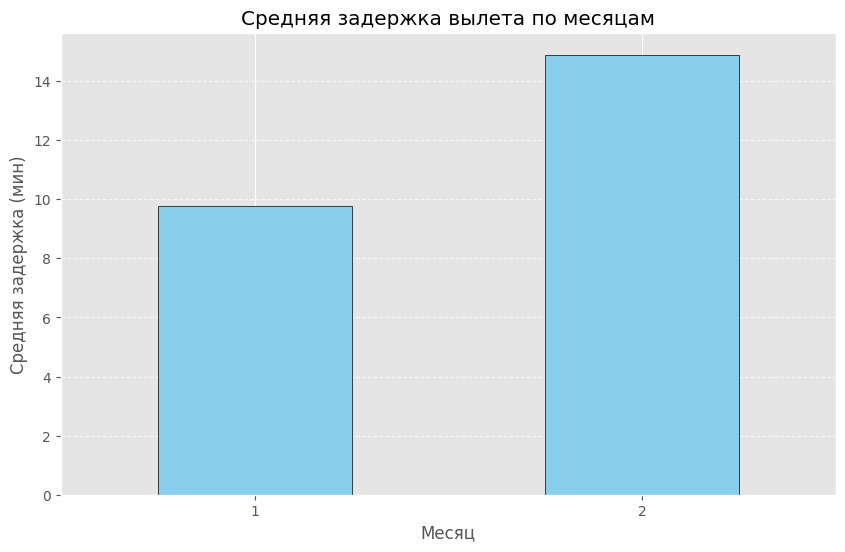

Месяц с самой большой средней задержкой: 2


In [28]:
# Группируем по месяцам и считаем среднюю задержку
monthly_delay = df.groupby('MONTH')['DEPARTURE_DELAY'].mean()

plt.figure(figsize=(10, 6))
monthly_delay.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Средняя задержка вылета по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Средняя задержка (мин)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Месяц с самой большой средней задержкой: {monthly_delay.idxmax()}")

### 2. Какие авиакомпании самые пунктуальные?
Сравним перевозчиков по среднему времени задержки вылета, чтобы понять, чьими услугами надежнее пользоваться.

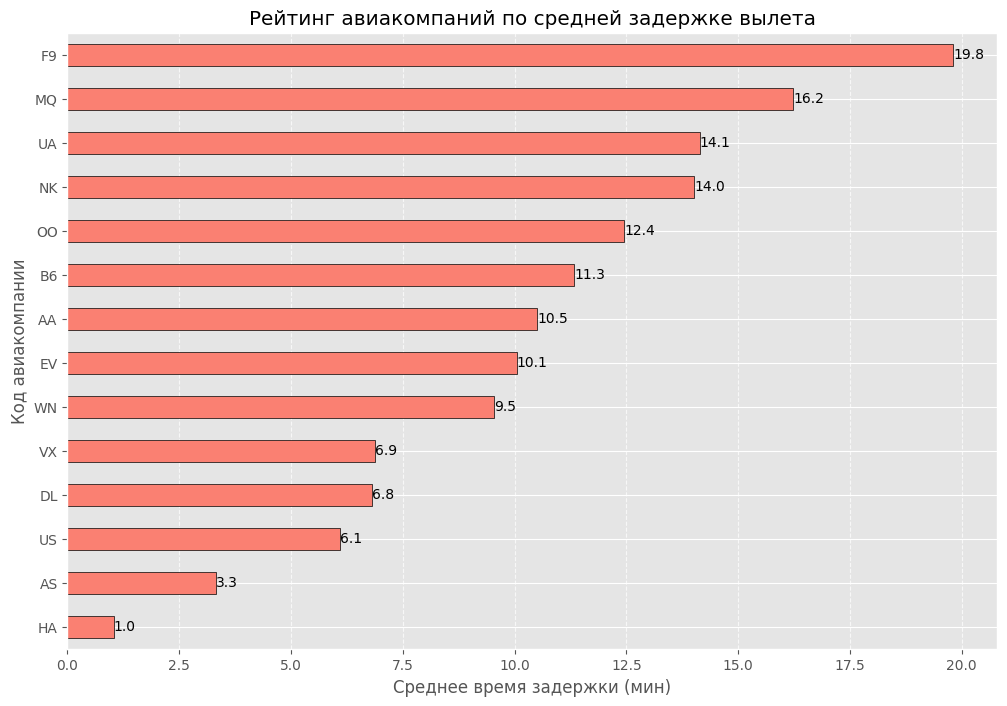

In [29]:
# Группируем по авиакомпаниям
airline_stats = df.groupby('AIRLINE')['DEPARTURE_DELAY'].mean().sort_values()

plt.figure(figsize=(12, 8))
airline_stats.plot(kind='barh', color='salmon', edgecolor='black')
plt.title('Рейтинг авиакомпаний по средней задержке вылета')
plt.xlabel('Среднее время задержки (мин)')
plt.ylabel('Код авиакомпании')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for index, value in enumerate(airline_stats):
    plt.text(value, index, f'{value:.1f}', va='center')

plt.show()

### 3. Накапливаются ли задержки в течение дня?
Построим график зависимости средней задержки от часа запланированного вылета. Часто утренние рейсы вылетают вовремя, а к вечеру задержки нарастают из-за эффекта "снежного кома".

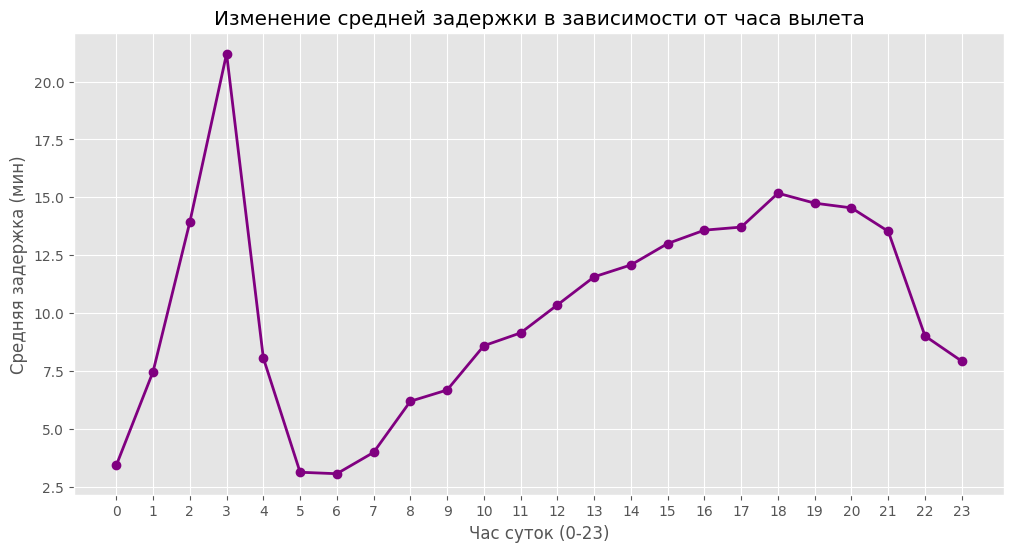

In [30]:
# Группируем по часу вылета
hourly_delay = df.groupby('HOUR')['DEPARTURE_DELAY'].mean()

plt.figure(figsize=(12, 6))
hourly_delay.plot(kind='line', marker='o', color='purple', linewidth=2)
plt.title('Изменение средней задержки в зависимости от часа вылета')
plt.xlabel('Час суток (0-23)')
plt.ylabel('Средняя задержка (мин)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

### 4. Каковы основные причины задержек?
Датасет содержит информацию о причинах задержек (погода, безопасность, вина авиакомпании и т.д.). Посмотрим на вклад каждого фактора в общее время задержек.

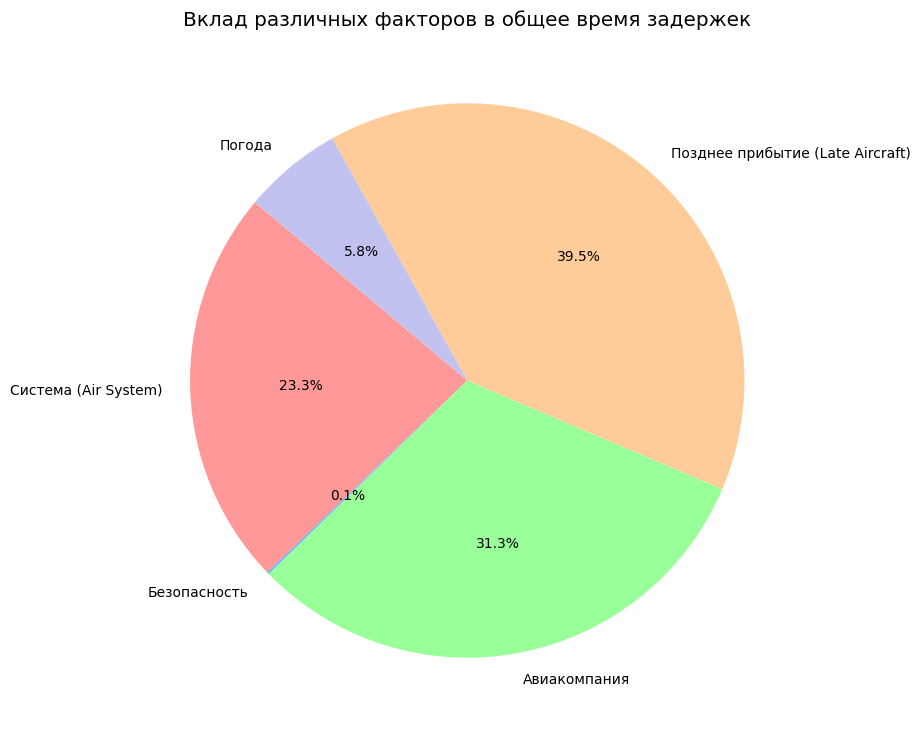

In [31]:
delay_reasons = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
                 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

reasons_sum = df[delay_reasons].sum()

labels = ['Система (Air System)', 'Безопасность', 'Авиакомпания',
          'Позднее прибытие (Late Aircraft)', 'Погода']

# Построение графика
plt.figure(figsize=(9, 9))
plt.pie(reasons_sum, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0'])
plt.title('Вклад различных факторов в общее время задержек')
plt.ylabel('')
plt.show()

### 5. В каких аэропортах ждать дольше всего?
Определим 10 аэропортов вылета с самой высокой средней задержкой. Это может указывать на перегруженность узлов или плохую организацию.

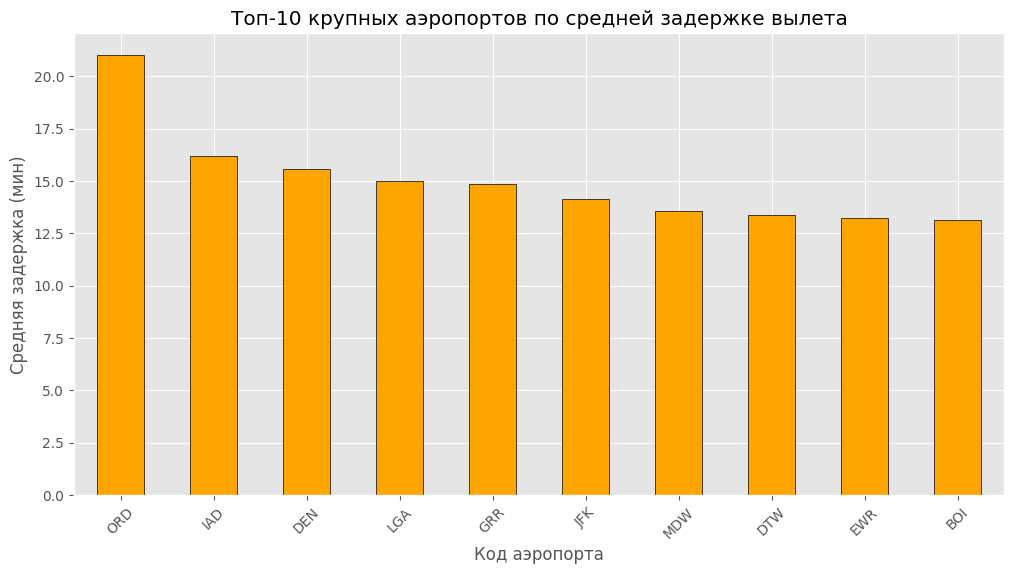

In [32]:
# Фильтруем аэропорты, где было хотя бы 1000 рейсов
airport_counts = df['ORIGIN_AIRPORT'].value_counts()
large_airports = airport_counts[airport_counts > 1000].index

# Считаем среднюю задержку только для крупных аэропортов и берем топ-10 худших
top_delay_airports = df[df['ORIGIN_AIRPORT'].isin(large_airports)]\
                        .groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY']\
                        .mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_delay_airports.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Топ-10 крупных аэропортов по средней задержке вылета')
plt.xlabel('Код аэропорта')
plt.ylabel('Средняя задержка (мин)')
plt.xticks(rotation=45)
plt.show()

### Выводы

На основе проведенного анализа данных за 2015 год можно сделать следующие заключения:

1.  **Сезонность:** На графике №1 видно, что пики задержек приходятся на летние месяцы (июнь-июль) и зимний период (декабрь, февраль), что вероятно связано с сезонами отпусков и погодными условиями. Осень (сентябрь-октябрь) — самое спокойное время для полетов.
2.  **Авиакомпании:** График №2 показывает значительный разброс в пунктуальности. Бюджетные авиакомпании (например, NK - Spirit Airlines) часто имеют более высокие показатели задержек по сравнению с крупными сетевыми перевозчиками (например, HA - Hawaiian Airlines).
3.  **Время суток:** График №3 четко демонстрирует накопительный эффект задержек. Утренние рейсы (4-6 утра) вылетают с минимальными опозданиями, но к вечеру (18:00-20:00) среднее время задержки достигает максимума. **Лучше летать утром.**
4.  **Причины:** Основной причиной суммарного времени задержек (График №4) является "Позднее прибытие самолета" (Late Aircraft Delay). Это подтверждает проблему цепочки задержек: опоздание одного рейса сдвигает расписание для следующего.
5.  **Аэропорты:** Анализ выявил конкретные аэропорты с систематическими проблемами со своевременным вылетом, которые пассажирам стоит учитывать при планировании пересадок.

**Общий итог:** Аэропорты действительно не справляются с неравномерной нагрузкой, что подтверждается ростом задержек к вечеру и в пиковые месяцы. Проблема позднего прибытия самолетов является доминирующей, создавая цепную реакцию в расписании.